A. EDA có cấu trúc 

Chuẩn bị

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv("users_7_7_2026 2_49_38 AM.csv")

# Chuyển cột ngày
df["When created"] = pd.to_datetime(
    df["When created"],
    errors="coerce"
)

plt.style.use("default")

1. Tăng trưởng tài khoản theo năm

When created
2018     17
2019      6
2020    125
2021    136
2022    184
2023    325
2024    288
2025    532
2026    287
Name: count, dtype: int64


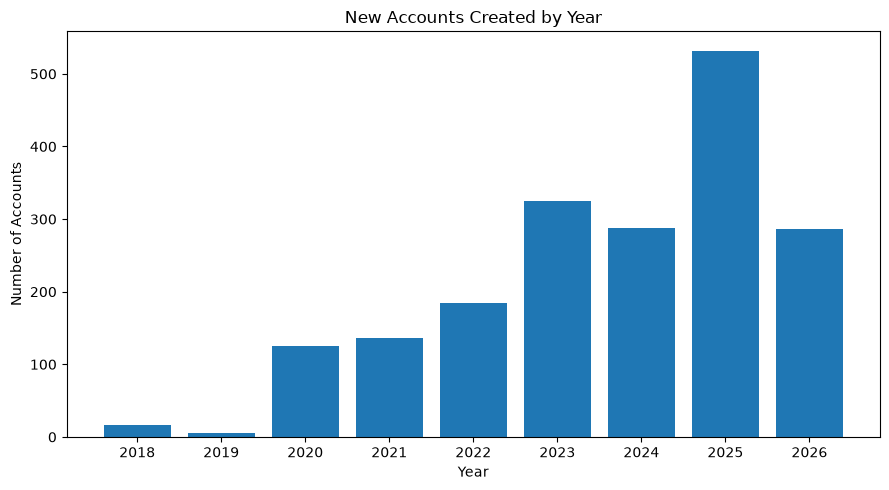

In [25]:
accounts_per_year = (
    df["When created"]
    .dt.year
    .value_counts()
    .sort_index()
)

print(accounts_per_year)

plt.figure(figsize=(9,5))

plt.bar(
    accounts_per_year.index.astype(str),
    accounts_per_year.values
)

plt.title("New Accounts Created by Year")
plt.xlabel("Year")
plt.ylabel("Number of Accounts")

plt.tight_layout()
plt.show()

2. Top 10 Department

Department
Điện, điện nhẹ     16
TDI E&C            25
PKD                26
PQS                46
TDME               60
PTC               104
BKVN              105
XL247             112
TDI               324
Unknown           959
Name: count, dtype: int64


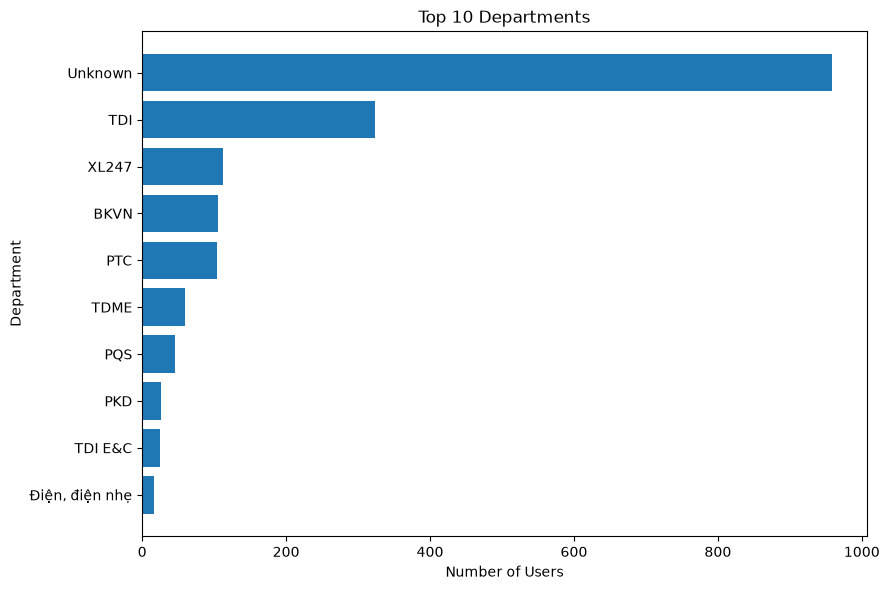

In [26]:
top_department = (
    df["Department"]
    .fillna("Unknown")
    .value_counts()
    .head(10)
    .sort_values()
)

print(top_department)

plt.figure(figsize=(9,6))

plt.barh(
    top_department.index,
    top_department.values
)

plt.title("Top 10 Departments")
plt.xlabel("Number of Users")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

3. Chất lượng dữ liệu

AgeGroup                           100.000000
Soft deletion time stamp           100.000000
Preferred data location            100.000000
Fax                                100.000000
Last dirsync time                  100.000000
Phone number                        99.631579
City                                98.421053
Title                               96.421053
Postal code                         95.052632
Street address                      95.000000
StateOrProvince                     94.684211
CountryOrRegion                     94.210526
Preferred language                  93.000000
Department                          50.473684
Office                              15.842105
Mobile Phone                        13.842105
Last name                           10.315789
First name                           9.263158
Usage location                       8.368421
Proxy addresses                      1.105263
Display name                         0.000000
When created                      

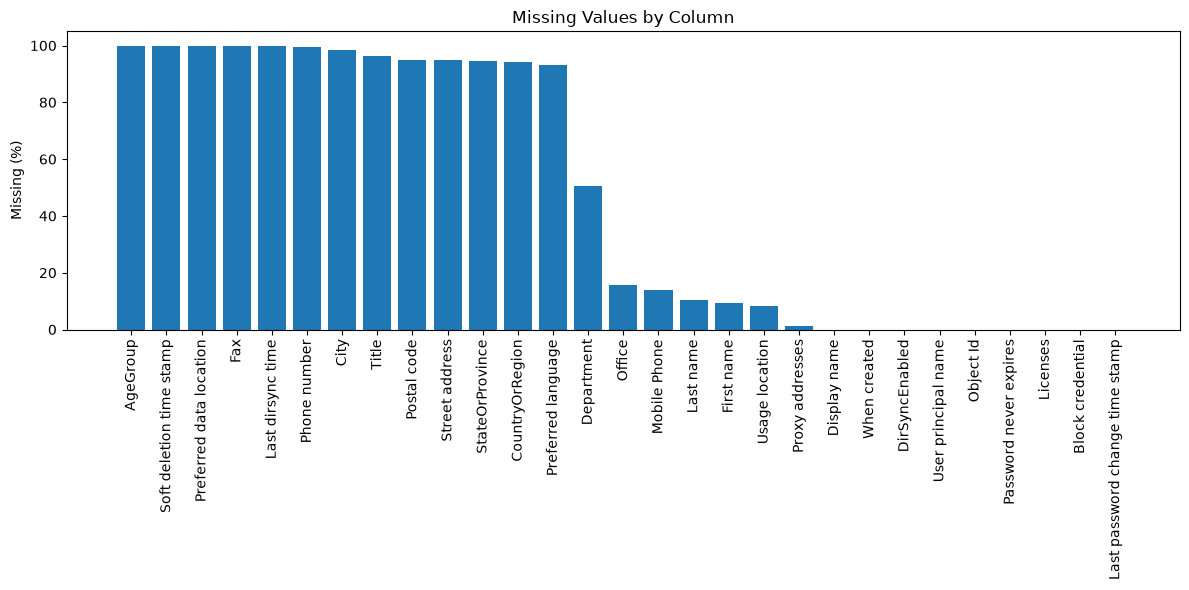

In [27]:
missing = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(missing)

plt.figure(figsize=(12,6))

plt.bar(
    missing.index,
    missing.values
)

plt.xticks(rotation=90)

plt.ylabel("Missing (%)")

plt.title("Missing Values by Column")

plt.tight_layout()
plt.show()

4. Biểu đồ bảo mật

       Password never expires  Block credential
False                     0.0              1056
True                   1900.0               844


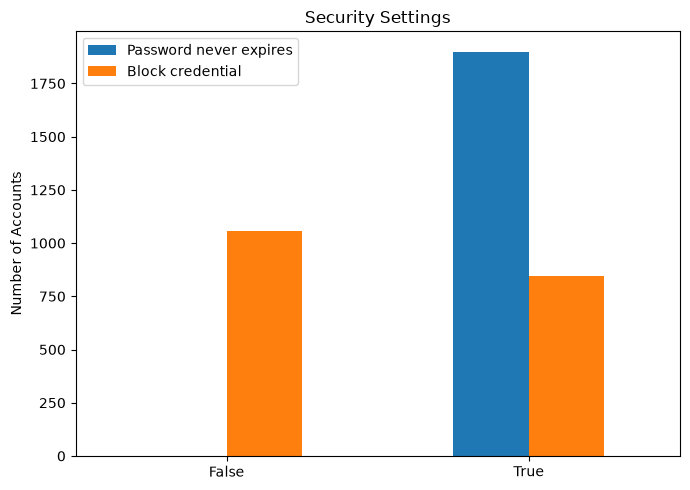

In [ ]:
security = pd.DataFrame({
    "Password never expires":
        df["Password never expires"].value_counts(),

    "Block credential":
        df["Block credential"].value_counts()
}).fillna(0)

print(security)

security.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Security Settings")

plt.ylabel("Number of Accounts")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

B. Rút 3 insight

Insight 1 : Tăng trưởng

Năm 2025 là năm có tốc độ tạo tài khoản cao nhất với 532 tài khoản, tăng khoảng 85% so với năm 2024 (288 tài khoản). Đây là dấu hiệu cho thấy doanh nghiệp có một đợt mở rộng quy mô đáng kể. Cần rà soát quy trình tạo tài khoản và lập kế hoạch cấp phát tài nguyên CNTT để đáp ứng các đợt tăng trưởng lớn, đồng thời đánh giá nguyên nhân của sự sụt giảm xuống còn 287 tài khoản trong năm 2026 (dữ liệu có thể chưa đủ cả năm hoặc nhu cầu tuyển dụng đã giảm).

Insight 2 : Bảo mật

100% tài khoản (1.900/1.900) được cấu hình Password never expires, trong khi có 844 tài khoản (44,4%) đang ở trạng thái bị chặn (Block credential = True). Việc toàn bộ tài khoản không hết hạn mật khẩu là một kết quả bất thường đối với môi trường doanh nghiệp, vì làm tăng rủi ro nếu mật khẩu bị lộ hoặc không được thay đổi định kỳ. Doanh nghiệp nên kiểm tra lại chính sách mật khẩu hiện hành hoặc xác minh xem dữ liệu xuất ra có phản ánh đúng cấu hình thực tế hay không. Đồng thời, cần rà soát định kỳ các tài khoản bị chặn để xác định nguyên nhân (nhân viên nghỉ việc, tài khoản không còn sử dụng hoặc bị khóa do sự cố) và xử lý phù hợp.

Insight 3 : Chất lượng dữ liệu

Hơn một nửa tài khoản (50,47%) không có thông tin Department, trong khi City và Title lần lượt thiếu tới 98,42% và 96,42%. Điều này cho thấy dữ liệu người dùng chưa đủ đầy để phân tích cơ cấu tổ chức hoặc phân bố nhân sự theo địa điểm. Doanh nghiệp nên ưu tiên chuẩn hóa việc nhập thông tin khi tạo tài khoản và đồng bộ dữ liệu từ hệ thống HR để nâng cao chất lượng báo cáo.

C. Tóm tắt

Qua phân tích dữ liệu, số lượng tài khoản tăng mạnh qua các năm và đạt mức cao nhất vào năm 2025, cho thấy doanh nghiệp đã có giai đoạn mở rộng quy mô đáng kể. Tuy nhiên, nhiều tài khoản vẫn thiếu thông tin quan trọng như phòng ban, chức danh và địa điểm làm việc, khiến việc thống kê và quản lý nhân sự chưa đạt hiệu quả. Ngoài ra, toàn bộ tài khoản hiện được thiết lập không yêu cầu thay đổi mật khẩu định kỳ, đây là điểm cần được kiểm tra để đảm bảo an toàn thông tin. Doanh nghiệp nên ưu tiên hoàn thiện thông tin người dùng khi tạo tài khoản, rà soát lại chính sách bảo mật và thường xuyên kiểm tra các tài khoản không còn sử dụng nhằm nâng cao chất lượng dữ liệu và giảm rủi ro trong quá trình quản lý.